In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load your dataset (replace with your file path if needed)
df = pd.read_csv("/content/drive/MyDrive/colab csv/House Price Prediction Dataset.csv")

# Quick overview
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban   

Exploratory Data Analysis EDA

Missing values per column:
 Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Descriptive statistics:
                 Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.92669

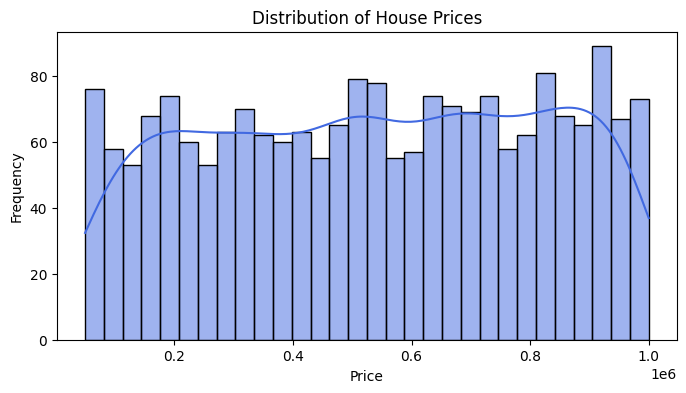

In [ ]:
# 1. Null check and summary statistics
print("Missing values per column:\n", df.isnull().sum())
print("\nDescriptive statistics:\n", df.describe())

# 2. Distribution of the target variable (Price)
plt.figure(figsize=(8, 4))
sns.histplot(df["Price"], kde=True, bins=30, color="royalblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Correlation Heatmap & Feature Selection Discussion

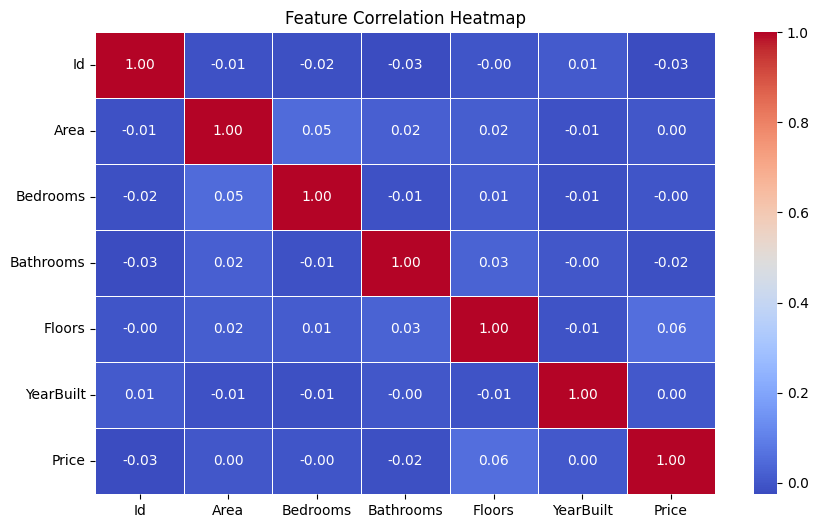

In [ ]:
# Filter numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Markdown Explanation for Feature Selection:
Area / Square Footage: Typically exhibits the strongest positive linear relationship with price, as larger physical capacity commands higher valuation.

Location / Neighborhood: Captures spatial premiums (e.g., proximity to city center, schools, transit).

Number of Rooms / Bedrooms / Bathrooms: Directly tied to usability and capacity.

Age of House: Generally expected to have a negative coefficient (older properties depreciate, unless historical/renovated).

Data Preprocessing & Pipeline Setup

In [ ]:
# Separate features and target
X = df.drop(columns=["Price"])
y = df["Price"]

# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocessing pipelines for numeric and categorical data
numeric_transformer = SimpleImputer(strategy="median")
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Train/Test Split (80/20) and Model Training

In [ ]:
# Split the raw data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Create and train the linear regression pipeline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

# Generate predictions
y_pred_train = lr_pipeline.predict(X_train)
y_pred_test = lr_pipeline.predict(X_test)

 Model Evaluation (MSE, RMSE, $R^2$)

In [ ]:
# Calculate evaluation metrics on the test set
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("--- Model Evaluation (Test Set) ---")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

--- Model Evaluation (Test Set) ---
MSE:  78,279,764,120.86
RMSE: 279,785.21
R²:   -0.0062


Diagnostic Visualizations

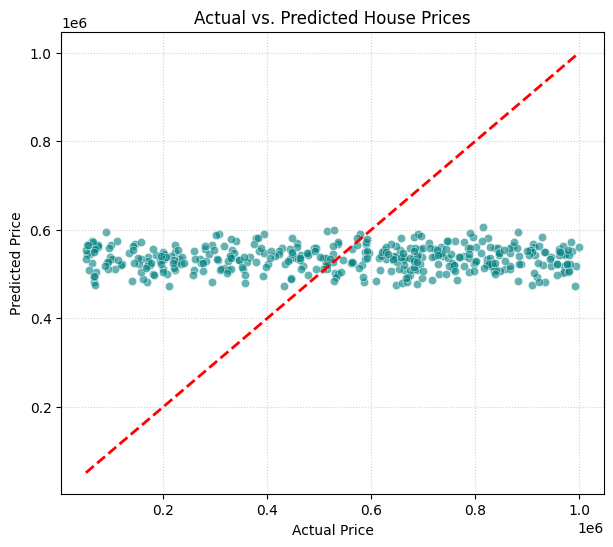

In [ ]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Prices")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

Residual Plot

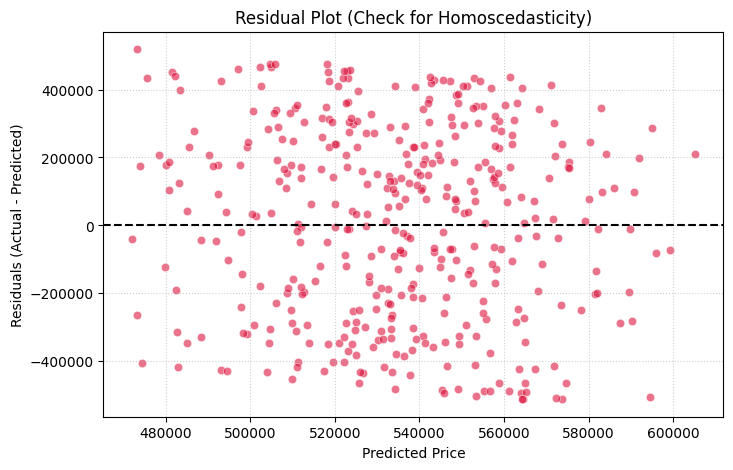

In [ ]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.6, color="crimson")
plt.axhline(0, color="black", linestyle="--", lw=1.5)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Check for Homoscedasticity)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

Coefficient Analysis

In [ ]:
# Extract feature names after One-Hot Encoding
encoded_cat_features = lr_pipeline.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(encoded_cat_features)
coefficients = lr_pipeline.named_steps["regressor"].coef_

coeff_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print("Top Positive & Negative Features:\n", coeff_df)

Top Positive & Negative Features:
               Feature   Coefficient
9      Condition_Fair  24049.504733
4              Floors  23582.408499
7   Location_Suburban  11110.139855
11     Condition_Poor   4389.783506
12         Garage_Yes   2218.649484
6      Location_Rural   1826.466887
5           YearBuilt    116.775334
2            Bedrooms     53.249124
1                Area     -0.484192
0                  Id    -12.007473
3           Bathrooms  -9835.704344
8      Location_Urban -12601.589640
10     Condition_Good -13048.175894


(Bonus) Ridge & Lasso Regularization Comparison

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=1.0, max_iter=5000)
}

comparison_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    comp_mse = mean_squared_error(y_test, preds)
    comp_rmse = np.sqrt(comp_mse)
    comp_r2 = r2_score(y_test, preds)

    comparison_results.append({
        "Model": name,
        "RMSE": comp_rmse,
        "R² Score": comp_r2
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_markdown(index=False))

| Model             |   RMSE |    R² Score |
|:------------------|-------:|------------:|
| Linear Regression | 279785 | -0.00618178 |
| Ridge (L2)        | 279785 | -0.00617881 |
| Lasso (L1)        | 279785 | -0.00618045 |
